# Case 4: latent dynamic debuggerOne simulation is shared by our directed structural estimator, LPCMCI's native DPAG output, and the native Liéois sparse-plus-low-rank AR decomposition. These objects are compared only where their semantics agree.

In [1]:
from pathlib import Path
import sys, importlib.util, numpy as np, matplotlib.pyplot as plt, pandas as pd
from IPython.display import display
ROOT=Path.cwd().resolve(); ROOT=ROOT.parent if ROOT.name=='notebooks' else ROOT
sys.path.insert(0,str(ROOT/'src'))
from causal_opt.simulation import simulate_svar
from causal_opt.methods.dynamic_latent import fit_dynamic_latent
from causal_opt.evaluation.dynamic_metrics import dynamic_metrics, support_metrics
from causal_opt.evaluation.latent_metrics import latent_metrics
cfg=dict(T=100,d=3,p=1,seed=11,s0=3,k=1,burn_in=60,lag_sparsity=.20,latent_process='iid',min_latent_children=2)
thresholds=dict(w0_threshold=.05,wlag_threshold=.05)
liegeois_cfg=dict(backend='matlab_subprocess',repo_path=ROOT/'external'/'SparseLowRankIdentification',lambda_value=.004,gamma=1.25,maxiter=10,compute_relative_duality_gap=False,timeout=300)
print('Configuration:',cfg)
print('LPCMCI availability:', 'available' if importlib.util.find_spec('tigramite') else 'unavailable: install Tigramite in this kernel environment (no pinned project requirement is present)')

Configuration: {'T': 100, 'd': 3, 'p': 1, 'seed': 11, 's0': 3, 'k': 1, 'burn_in': 60, 'lag_sparsity': 0.2, 'latent_process': 'iid', 'min_latent_children': 2}
LPCMCI availability: available


## One shared Case 4 realization

T=100, d=3, p=1, k=1
companion spectral radius=0.9025; cond(I-W0)=20.6261


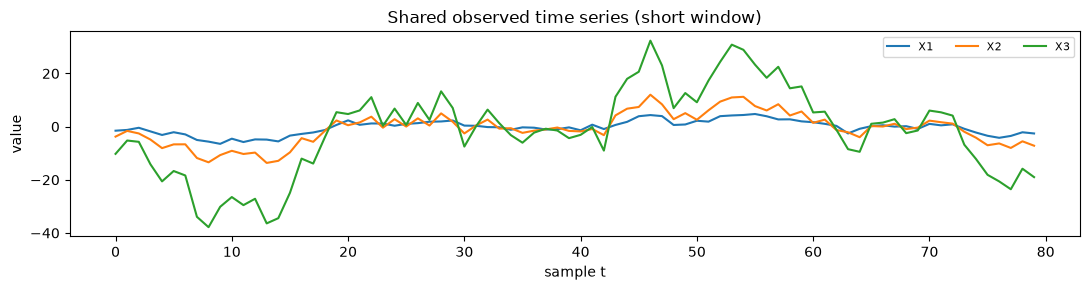

In [2]:
data=simulate_svar(**cfg); T,d=data.X.shape; p=cfg['p']
print(f'T={T}, d={d}, p={p}, k={cfg["k"]}')
print(f'companion spectral radius={data.spectral_radius:.6g}; cond(I-W0)={data.condition_number:.6g}')
window=min(80,T); fig,ax=plt.subplots(figsize=(11,3)); ax.plot(data.X[:window]); ax.set(xlabel='sample t',ylabel='value',title='Shared observed time series (short window)'); ax.legend([f'X{j+1}' for j in range(d)],ncol=d,fontsize=8); plt.tight_layout()

## A. Our directed structural and latent-factor estimate

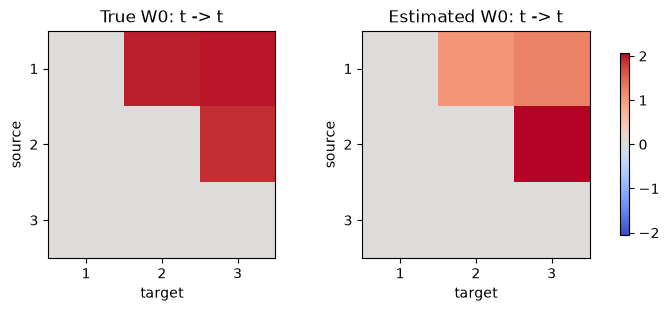

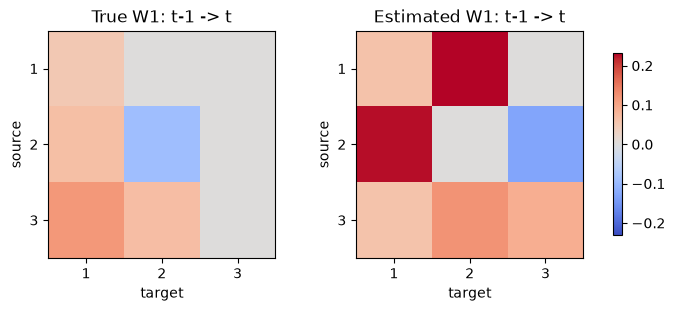

In [3]:
ours=fit_dynamic_latent(data.X,p,k=cfg['k'],lambda_0=.05,lambda_lag=.02,lambda_latent=.05,w0_threshold=thresholds['w0_threshold'],wlag_threshold=thresholds['wlag_threshold'],max_outer_iter=8,inner_max_iter=80,random_state=cfg['seed'])
our_metrics=dynamic_metrics(data.W0_true,data.W_lags_true,ours.W0,ours.W_lags,data.X,**thresholds)
our_latent=latent_metrics(data.C_true,ours.C,data.L_true,ours.L)
def pair_heatmaps(truth,estimate,title):
    limit=max(np.max(np.abs(truth)),np.max(np.abs(estimate))) or 1; fig,axes=plt.subplots(1,2,figsize=(7,3),constrained_layout=True)
    for ax,m,label in zip(axes,[truth,estimate],[f'True {title}',f'Estimated {title}']):
        im=ax.imshow(m,cmap='coolwarm',vmin=-limit,vmax=limit,origin='upper'); ax.set_title(label); ax.set(xlabel='target',ylabel='source'); ax.set_xticks(range(d),range(1,d+1)); ax.set_yticks(range(d),range(1,d+1))
    fig.colorbar(im,ax=axes,shrink=.8); plt.show()
pair_heatmaps(data.W0_true,ours.W0,'W0: t -> t')
for tau in range(1,p+1): pair_heatmaps(data.W_lags_true[tau-1],ours.W_lags[tau-1],f'W{tau}: t-{tau} -> t')

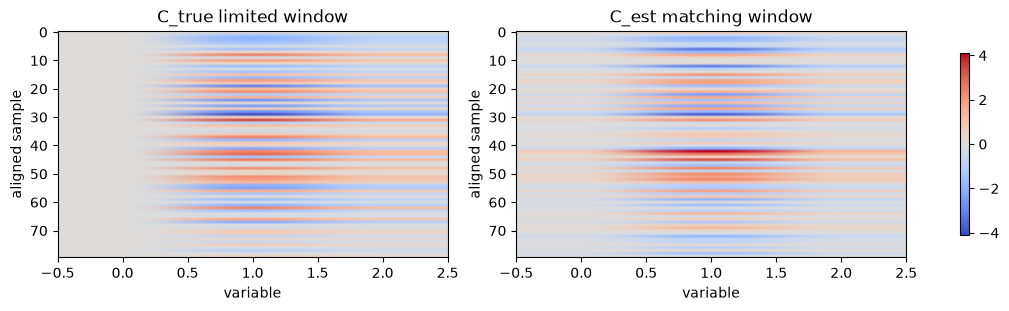

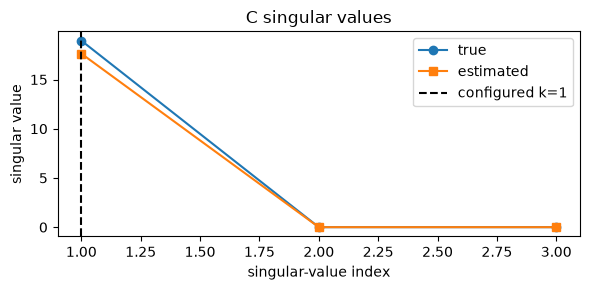

In [4]:
c_window=min(80,len(ours.C)); limit=max(np.max(np.abs(data.C_true[:c_window])),np.max(np.abs(ours.C[:c_window]))) or 1
fig,axes=plt.subplots(1,2,figsize=(10,3),constrained_layout=True)
for ax,m,label in zip(axes,[data.C_true[:c_window],ours.C[:c_window]],['C_true limited window','C_est matching window']): im=ax.imshow(m,aspect='auto',cmap='coolwarm',vmin=-limit,vmax=limit); ax.set(title=label,xlabel='variable',ylabel='aligned sample')
fig.colorbar(im,ax=axes,shrink=.8); plt.show()
s_true=np.linalg.svd(data.C_true,compute_uv=False); s_est=np.linalg.svd(ours.C,compute_uv=False); meaningful=min(10,len(s_true),len(s_est))
plt.figure(figsize=(6,3)); plt.plot(range(1,meaningful+1),s_true[:meaningful],'o-',label='true'); plt.plot(range(1,meaningful+1),s_est[:meaningful],'s-',label='estimated'); plt.axvline(cfg['k'],color='k',ls='--',label=f'configured k={cfg["k"]}'); plt.xlabel('singular-value index'); plt.ylabel('singular value'); plt.title('C singular values'); plt.legend(); plt.tight_layout()

W0 metrics


,precision,recall,f1,shd,weight_rmse,nnz
ours,1.0,1.0,1.0,0,0.39124,3


Per-lag metrics


,precision,recall,f1,shd,weight_rmse,nnz
lag,,,,,,
1,0.571429,0.8,0.666667,4,0.114748,7


Aggregate lag metrics


,precision,recall,f1,shd,weight_rmse,nnz
ours,0.571429,0.8,0.666667,4,0.114748,7


relative C error           0.595274
loading-subspace error     0.211789
effective rank             1.000000
||C||_F                   17.627934
||Z||_F / ||L||_F          1.000004
runtime                    0.464649
Name: ours, dtype: float64

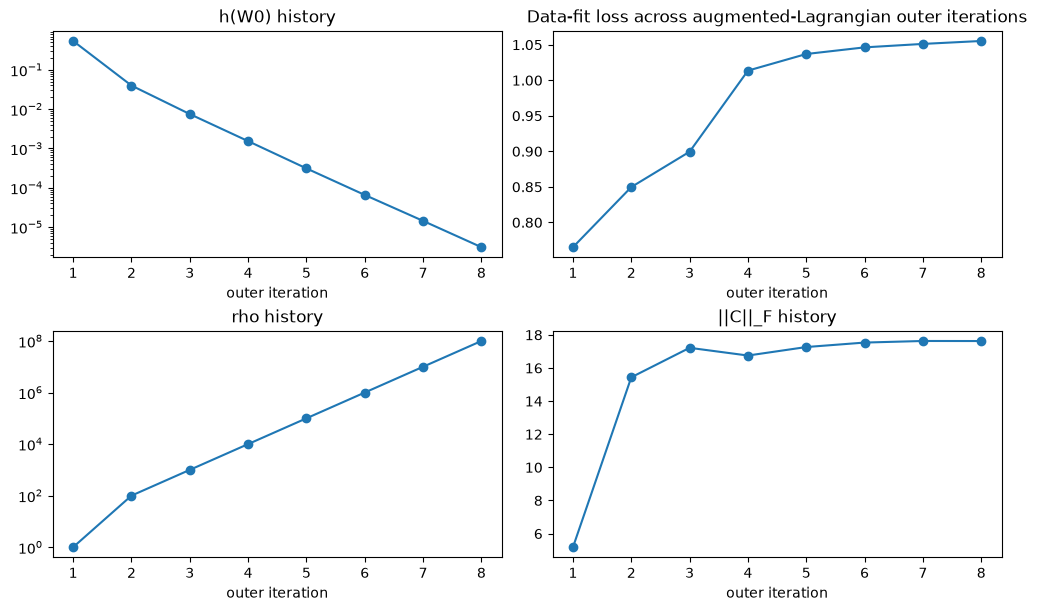

In [5]:
history=ours.diagnostics['history']; outer=[r['outer_iter'] for r in history]
fig,axes=plt.subplots(2,2,figsize=(10,6),constrained_layout=True)
axes[0,0].semilogy(outer,[max(r['h'],1e-18) for r in history],'o-'); axes[0,0].set_title('h(W0) history')
axes[0,1].plot(outer,[r['fit_loss'] for r in history],'o-'); axes[0,1].set_title('Data-fit loss across augmented-Lagrangian outer iterations')
axes[1,0].semilogy(outer,[r['rho'] for r in history],'o-'); axes[1,0].set_title('rho history')
axes[1,1].plot(outer,[r.get('C_fro_norm',np.nan) for r in history],'o-'); axes[1,1].set_title('||C||_F history')
for ax in axes.flat: ax.set_xlabel('outer iteration')
metric_cols=['precision','recall','f1','shd','weight_rmse','nnz']
print('W0 metrics'); display(pd.DataFrame([{k:our_metrics['W0'][k] for k in metric_cols}],index=['ours']))
print('Per-lag metrics'); display(pd.DataFrame([{**{'lag':tau+1},**{k:our_metrics['lags'][tau][k] for k in metric_cols}} for tau in range(p)]).set_index('lag'))
print('Aggregate lag metrics'); display(pd.DataFrame([{k:our_metrics['lag_aggregate'][k] for k in metric_cols}],index=['ours']))
display(pd.Series({'relative C error':our_latent['c_reconstruction_error'],'loading-subspace error':our_latent['loading_subspace_error'],'effective rank':ours.diagnostics['effective_rank_C'],'||C||_F':ours.diagnostics['C_fro_norm'],'||Z||_F / ||L||_F':ours.diagnostics['factor_balance_ratio'],'runtime':ours.runtime_seconds},name='ours'))

## Optional reference baselinesEach adapter is isolated so a missing dependency is reported without preventing later cells from running.

In [6]:
lpcmci=None; lpcmci_error=None
try:
    from causal_opt.baselines.lpcmci import fit_lpcmci
    lpcmci=fit_lpcmci(data.X,tau_max=p,pc_alpha=.05)
except (ImportError,ModuleNotFoundError,RuntimeError) as exc:
    lpcmci_error=f'{type(exc).__name__}: {exc}'; print('LPCMCI unavailable; continuing:',lpcmci_error)
liegeois=None; liegeois_error=None
try:
    from causal_opt.baselines.liegeois import fit_liegeois
    liegeois=fit_liegeois(data.X,p=p,**liegeois_cfg)
except (ImportError,RuntimeError) as exc:
    liegeois_error=f'{type(exc).__name__}: {exc}'; print('Liéois unavailable; continuing:',liegeois_error)

## B. LPCMCI: native DPAG endpoints and adjacency-only comparisonsLPCMCI endpoint symbols are not coerced into a directed weighted DAG. Common Tigramite notation: `-->` tail-to-arrow, `<--` arrow-to-tail, `o->` circle-to-arrow, `<-o` arrow-to-circle, and `o-o` unresolved circles. The displayed native array is authoritative; adjacency plots use only whether an endpoint entry is present. Ordinary DAG SHD is intentionally omitted.

Native endpoint array shape: (3, 3, 2)


array([[['', ''],
        ['o-o', ''],
        ['o-o', '']],

       [['o-o', ''],
        ['', ''],
        ['o-o', '']],

       [['o-o', ''],
        ['o-o', ''],
        ['', '']]], dtype='<U3')

Endpoint counts: {'': 12, 'o-o': 6}
Adjacency by lag (False/True):


{'contemporaneous': array([[False,  True,  True],
        [ True, False,  True],
        [ True,  True, False]]),
 'lags': array([[[False, False, False],
         [False, False, False],
         [False, False, False]]])}

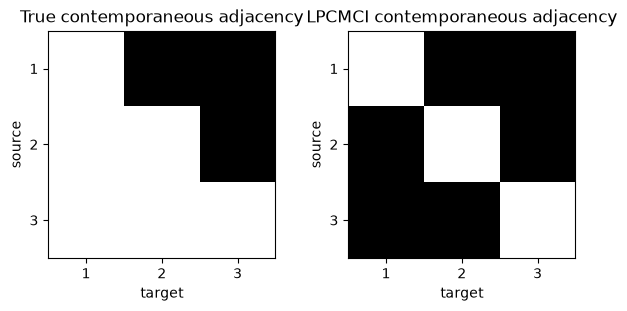

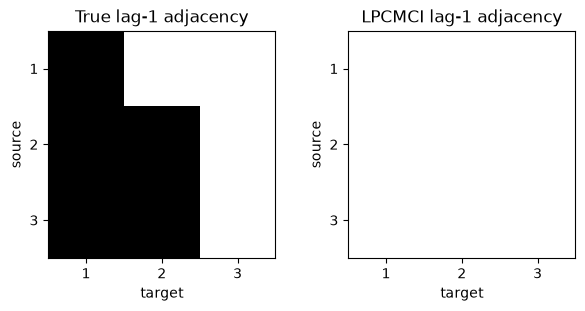

,precision,recall,F1
contemporaneous adjacency,0.5,1.0,0.666667


,precision,recall,F1
lag,,,
1,0.0,0.0,0.0


aggregate lag precision     0.000000
aggregate lag recall        0.000000
aggregate lag F1            0.000000
runtime                     0.069748
endpoint                   12.000000
endpoint o-o                6.000000
Name: LPCMCI, dtype: float64

In [7]:
lpcmci_metrics=None
if lpcmci is None:
    print('LPCMCI section unavailable:',lpcmci_error)
else:
    graph=np.asarray(lpcmci.graph); print('Native endpoint array shape:',graph.shape); display(graph); print('Endpoint counts:',lpcmci.diagnostics['endpoint_symbol_counts'])
    contemp=graph[:,:,0]!=''; np.fill_diagonal(contemp,False); lag_adj=np.stack([graph[:,:,tau]!='' for tau in range(1,p+1)])
    print('Adjacency by lag (False/True):'); display({'contemporaneous':contemp,'lags':lag_adj})
    true_c=np.asarray(data.W0_true)!=0; true_l=np.asarray(data.W_lags_true)!=0
    def adjacency_pair(truth,estimate,title):
        fig,axes=plt.subplots(1,2,figsize=(6,3),constrained_layout=True)
        for ax,m,label in zip(axes,[truth,estimate],[f'True {title}',f'LPCMCI {title}']): ax.imshow(m,cmap='Greys',vmin=0,vmax=1); ax.set_title(label); ax.set(xlabel='target',ylabel='source'); ax.set_xticks(range(d),range(1,d+1)); ax.set_yticks(range(d),range(1,d+1))
        plt.show()
    adjacency_pair(true_c,contemp,'contemporaneous adjacency')
    for tau in range(p): adjacency_pair(true_l[tau],lag_adj[tau],f'lag-{tau+1} adjacency')
    cm=support_metrics(true_c,contemp,0); lag_rows=[support_metrics(true_l[t],lag_adj[t],0) for t in range(p)]; lm=support_metrics(true_l,lag_adj,0)
    lpcmci_metrics={'contemporaneous':cm,'lags':lag_rows,'lag_aggregate':lm}
    display(pd.DataFrame([{'precision':cm['precision'],'recall':cm['recall'],'F1':cm['f1']}],index=['contemporaneous adjacency']))
    display(pd.DataFrame([{'lag':i+1,'precision':m['precision'],'recall':m['recall'],'F1':m['f1']} for i,m in enumerate(lag_rows)]).set_index('lag'))
    display(pd.Series({'aggregate lag precision':lm['precision'],'aggregate lag recall':lm['recall'],'aggregate lag F1':lm['f1'],'runtime':lpcmci.runtime_seconds,**{f'endpoint {k}':v for k,v in lpcmci.diagnostics['endpoint_symbol_counts'].items()}},name='LPCMCI'))

## C. Liéois: native sparse-plus-low-rank AR decompositionLiéois estimates a sparse-plus-low-rank autoregressive graphical-model decomposition. Its native `S`, `L`, `Omega`, and `Delta` are **not** our directed structural `W0`/`W_tau` parameters, so they are displayed separately and are not entered into directed-DAG metrics.

Provenance and configuration


upstream_commit               f9ca591039fb5c6a3288108e371ba328c7284e48
matlab_version                        24.2.0.3212159 (R2024b) Update 9
backend                                              matlab_subprocess
lambda                                                           0.004
gamma                                                             1.25
runtime_seconds                                              12.089137
estimated_latent_dimension                                           0
Name: Liéois, dtype: object

Native convergence information


cost_dual_final               4.494599e+00
cost_primal_final             4.494599e+00
relative_duality_gap_final    8.892458e-15
Name: infos, dtype: float64

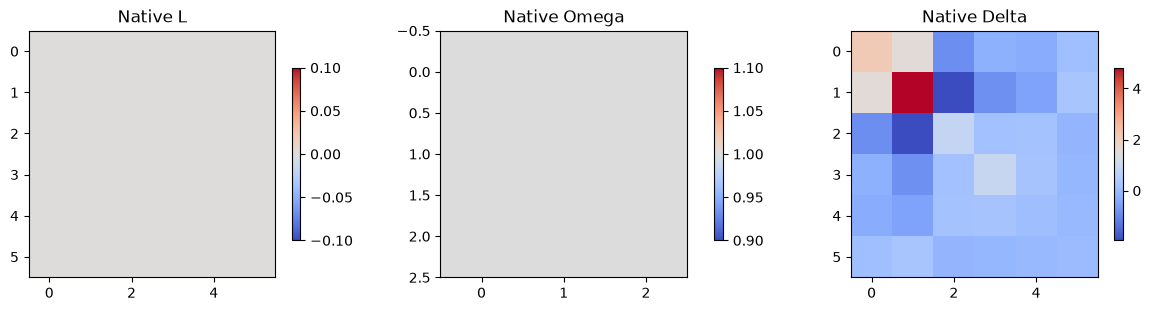

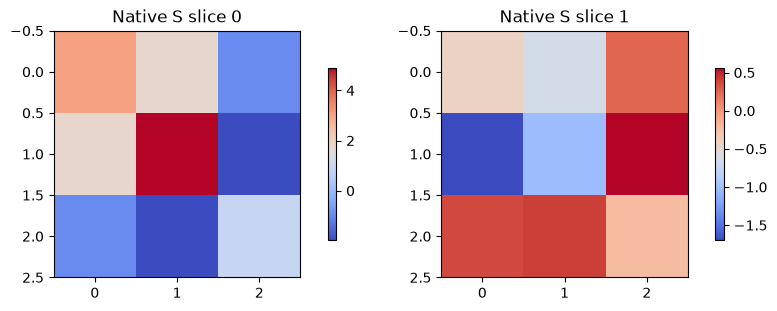

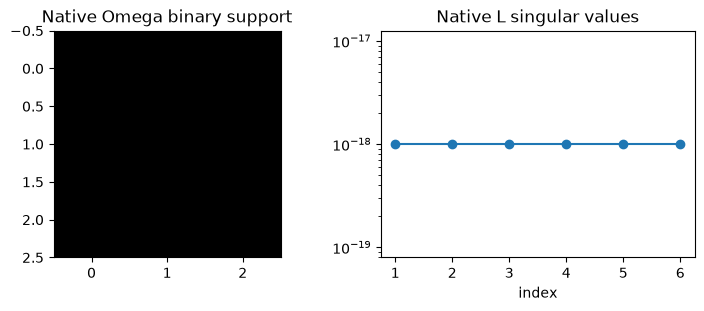

S nonzeros                18.000000
Omega support nonzeros     9.000000
rank(L)                    0.000000
estimated h                0.000000
runtime                   12.089137
Name: Liéois native statistics, dtype: float64

In [8]:
liegeois_summary=None
if liegeois is None:
    print('Liéois section unavailable:',liegeois_error)
else:
    xs=liegeois.native_result['x_sol']; diag=liegeois.diagnostics; infos=liegeois.native_result['infos']
    provenance={k:diag.get(k) for k in ('upstream_commit','matlab_version','backend','lambda','gamma','runtime_seconds','estimated_latent_dimension')}
    print('Provenance and configuration'); display(pd.Series(provenance,name='Liéois'))
    scalar_infos={k:np.asarray(v).item() for k,v in infos.items() if np.asarray(v).size==1}
    print('Native convergence information'); display(pd.Series(scalar_infos,name='infos'))
    L,S,Omega,Delta=[np.asarray(xs[k]) for k in ('L','S','Omega','Delta')]
    fig,axes=plt.subplots(1,3,figsize=(12,3),constrained_layout=True)
    for ax,m,label in zip(axes,[L,Omega,Delta],['Native L','Native Omega','Native Delta']): im=ax.imshow(m,cmap='coolwarm'); ax.set_title(label); fig.colorbar(im,ax=ax,shrink=.7)
    plt.show()
    fig,axes=plt.subplots(1,S.shape[2],figsize=(4*S.shape[2],3),squeeze=False,constrained_layout=True)
    for tau in range(S.shape[2]): im=axes[0,tau].imshow(S[:,:,tau],cmap='coolwarm'); axes[0,tau].set_title(f'Native S slice {tau}'); fig.colorbar(im,ax=axes[0,tau],shrink=.7)
    plt.show()
    fig,axes=plt.subplots(1,2,figsize=(7,3),constrained_layout=True); axes[0].imshow(Omega!=0,cmap='Greys',vmin=0,vmax=1); axes[0].set_title('Native Omega binary support'); axes[1].semilogy(np.arange(1,len(np.linalg.svd(L,compute_uv=False))+1),np.maximum(np.linalg.svd(L,compute_uv=False),1e-18),'o-'); axes[1].set_title('Native L singular values'); axes[1].set_xlabel('index'); plt.show()
    liegeois_summary={'S nonzeros':int(np.count_nonzero(S)),'Omega support nonzeros':int(np.count_nonzero(Omega)),'rank(L)':int(np.linalg.matrix_rank(L)),'estimated h':diag['estimated_latent_dimension'],'convergence':scalar_infos,'runtime':liegeois.runtime_seconds}
    display(pd.Series({k:v for k,v in liegeois_summary.items() if k!='convergence'},name='Liéois native statistics'))

## Comparison summaryThe three blocks below deliberately avoid a universal ranking across mathematically different output objects.

In [9]:
print('A. Directed structural recovery — OURS')
display(pd.DataFrame({'W0':{k:our_metrics['W0'][k] for k in ('precision','recall','f1','shd','weight_rmse')},'Wlag aggregate':{k:our_metrics['lag_aggregate'][k] for k in ('precision','recall','f1','shd','weight_rmse')}}).T)
print('B. Latent-aware causal adjacency — LPCMCI')
if lpcmci_metrics is None: print('Unavailable:',lpcmci_error)
else: display(pd.DataFrame({'contemporaneous adjacency':{k:lpcmci_metrics['contemporaneous'][k] for k in ('precision','recall','f1')},'lagged adjacency':{k:lpcmci_metrics['lag_aggregate'][k] for k in ('precision','recall','f1')}}).T); display(pd.Series(lpcmci.diagnostics['endpoint_symbol_counts'],name='endpoint counts'))
print('C. Sparse + low-rank AR decomposition — Liéois')
if liegeois_summary is None: print('Unavailable:',liegeois_error)
else: display(pd.Series(liegeois_summary,name='native decomposition summary'))
runtime={'ours':ours.runtime_seconds}
if lpcmci is not None: runtime['lpcmci']=lpcmci.runtime_seconds
if liegeois is not None: runtime['liegeois']=liegeois.runtime_seconds
print('Available-method runtimes'); display(pd.DataFrame({'seconds':runtime}))

A. Directed structural recovery — OURS


,precision,recall,f1,shd,weight_rmse
W0,1.000000,1.0,1.000000,0.0,0.391240
Wlag aggregate,0.571429,0.8,0.666667,4.0,0.114748


B. Latent-aware causal adjacency — LPCMCI


,precision,recall,f1
contemporaneous adjacency,0.5,1.0,0.666667
lagged adjacency,0.0,0.0,0.000000


       12
o-o     6
Name: endpoint counts, dtype: int64

C. Sparse + low-rank AR decomposition — Liéois


S nonzeros                                                               18
Omega support nonzeros                                                    9
rank(L)                                                                   0
estimated h                                                               0
convergence               {'cost_dual_final': 4.49459871603015, 'cost_pr...
runtime                                                           12.089137
Name: native decomposition summary, dtype: object

Available-method runtimes


,seconds
ours,0.464649
lpcmci,0.069748
liegeois,12.089137
